# DBscan example

## Dataset
- **Source**: EAFC26 Player Database (Men) from Kaggle.
- **Content**: Player ratings and metadata for male players in EA Sports FC 26.
- **Features**:
  - Continuous numeric attributes such as OVR, PAC, SHO, PAS, DRI, DEF, PHY, and detailed sub‑attributes (Acceleration, Sprint Speed, Finishing, Shot Power, etc.).
  - Categorical attributes such as Name, Nation, League, Team, Position, Preferred foot, Weak foot, Skill moves, Play style.
  - Goalkeeper‑specific attributes such as GK Diving, GK Handling, GK Kicking, GK Positioning, GK Reflexes.

## Data Cleaning
- Removed non‑continuous categorical columns (e.g., Name, Nation, League, Team, Position, Preferred foot).
- Removed goalkeeper‑specific columns.
- Dropped rows with missing or blank values.
- Retained only continuous numeric player attributes for analysis.

## Dimensionality Reduction
- Applied **Principal Component Analysis (PCA)** to the cleaned dataset.
- Reduced the feature space to two principal components for visualization and clustering.
- PCA captures the main variance in player attributes, projecting each player into a 2D space.

## Clustering
- Applied **DBSCAN** on the PCA output.
- DBSCAN groups players into clusters based on density in the reduced space.




Principal Component Vectors:
 [[-0.04935643 -0.04458838 -0.03860031 -0.0547786  -0.05332428 -0.10515096
  -0.03346012 -0.16356168 -0.15597293 -0.25531161 -0.23091506 -0.11757526
  -0.24171382 -0.20511294 -0.1756444  -0.23015784 -0.14338068 -0.20010258
  -0.18840961 -0.17600534 -0.23101206 -0.25189163 -0.16361713 -0.14571613
  -0.06619178 -0.22779231 -0.14390873 -0.18236975 -0.17930245 -0.18405583
  -0.18628177 -0.17224233 -0.07611093 -0.19802241 -0.03187823 -0.17258331]
 [-0.00348728  0.09678441  0.22902237  0.0509827   0.09704281 -0.31186167
  -0.09057212  0.0802285   0.06155704  0.15934139  0.22940985  0.13514785
   0.17597812  0.18029145  0.14097718  0.04058019  0.09768515  0.10634105
  -0.02837005 -0.05638108  0.10154298  0.08224871  0.10553576  0.07675181
  -0.01029347  0.02566431  0.00720632 -0.3562351  -0.10948191 -0.34916069
  -0.35795855 -0.36042525 -0.05603551 -0.07040847 -0.10401202 -0.17796876]]
Projected Data (2D):
 [[-135.14686615   73.41072107]
 [-127.53020258   93.37747

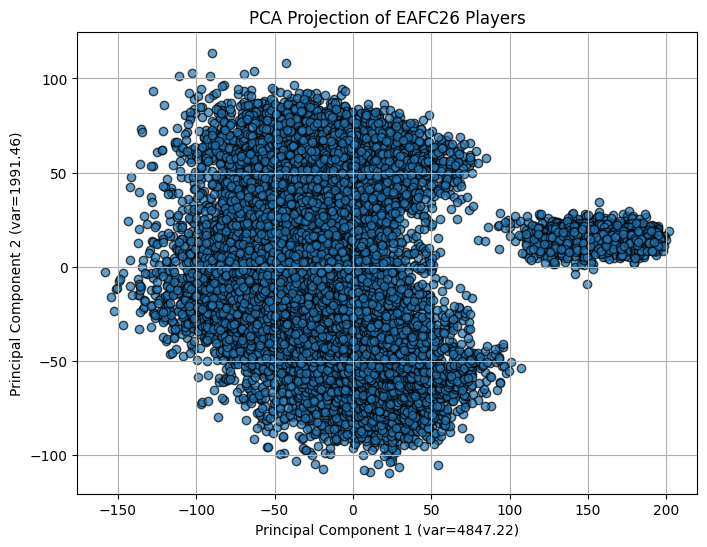

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from ml import compute_pca

df = pd.read_csv("EAFC26-Men.csv")


# Step 1: Drop GENDER column
df = df.drop(columns=['GENDER'], errors='ignore')

# Step 2: Drop GK-specific stats
gk_stats = ['GK Diving','GK Handling','GK Kicking','GK Positioning','GK Reflexes']
df = df.drop(columns=gk_stats, errors='ignore')

# Step 3: Drop non-continuous / categorical columns
non_continuous = [
    'ID','Rank','Name','Position','Weak foot','Skill moves',
    'Preferred foot','Height','Weight','Alternative positions','Age',
    'Nation','League','Team','play style','url','card'
]
df = df.drop(columns=non_continuous, errors='ignore')

# Step 4: Compute mean of continuous stats
mean_stats = df.mean(numeric_only=True)

X = df.to_numpy()

# Run PCA with 2 components
components, explained_variance, transformed_data = compute_pca(X, n_components=2)

# Two vectors:
# 1. The principal component vectors (shape: (2, n_features))
pc_vectors = components

# 2. The transformed data (projection onto the 2 components, shape: (n_samples, 2))
pc_projection = transformed_data

print("Principal Component Vectors:\n", pc_vectors)
print("Projected Data (2D):\n", pc_projection)


plt.figure(figsize=(8,6))
plt.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.7, edgecolors='k')

plt.xlabel(f'Principal Component 1 (var={explained_variance[0]:.2f})')
plt.ylabel(f'Principal Component 2 (var={explained_variance[1]:.2f})')
plt.title('PCA Projection of EAFC26 Players')
plt.grid(True)
plt.show()






The PCA projection reveals what appear to be two distinct clusters of players. While attributes like position were not explicitly included in the analysis, it's possible that the group on the right corresponds to goalkeepers, given their unique statistical profiles. Next, we apply DBSCAN to classify these players based on density in the reduced feature space. We expect DBSCAN to identify and separate the two visible groups effectively.

In [8]:
from ml import dbscan

labels = dbscan(pc_projection, eps=5, min_samples=5)

# Count how many distinct clusters (excluding noise = -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print(f"Number of clusters found: {n_clusters}")



KeyboardInterrupt: 

C:\Users\btmay\AppData\Local\Temp\ipykernel_27044\2507721281.py:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


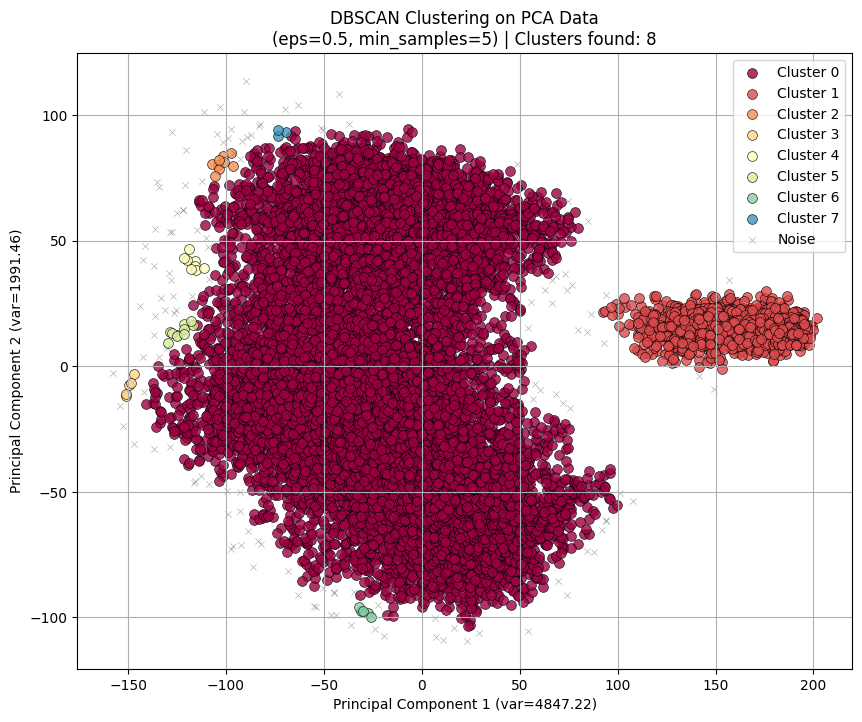

In [ ]:
# --- Visualization of DBSCAN Results ---

# Get all unique labels found by DBSCAN
import numpy as np


unique_labels = set(labels)

# Create a new figure
plt.figure(figsize=(10, 8))

# Define a colormap (using 'tab10' or 'viridis' for distinct cluster colors)
# We generate enough colors for the clusters
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]
        label_name = "Noise"
        marker = 'x'  # Mark noise with an 'x'
        size = 20
        alpha = 0.3   # Make noise slightly transparent
    else:
        label_name = f"Cluster {k}"
        marker = 'o'
        size = 50
        alpha = 0.8

    # Create a mask for points belonging to the current label
    class_member_mask = (labels == k)

    # Plot the points for this specific cluster/noise
    xy = pc_projection[class_member_mask]
    plt.scatter(
        xy[:, 0], 
        xy[:, 1], 
        s=size, 
        c=[col], 
        marker=marker, 
        label=label_name, 
        alpha=alpha,
        edgecolors='k',
        linewidths=0.5
    )

plt.title(f'DBSCAN Clustering on PCA Data\n(eps=0.5, min_samples=5) | Clusters found: {n_clusters}')
plt.xlabel(f'Principal Component 1 (var={explained_variance[0]:.2f})')
plt.ylabel(f'Principal Component 2 (var={explained_variance[1]:.2f})')

# Add legend (if too many clusters, you might want to comment this out)
if len(unique_labels) < 20: 
    plt.legend(loc='best')

plt.grid(True)
plt.show()

In [9]:
from ml import compute_noise_fraction
compute_noise_fraction(labels)

0.008195711116588612

The algorithm successfully identified two distinct, large, and dense clusters (Cluster 0, predominantly the large maroon/dark red area, and Cluster 1, the red/orange area on the right). This confirms the observation that DBSCAN does a good job of isolating these major dense regions. The vast majority of data points are assigned to these two clusters.Minor Clusters (Cluster 2 - Cluster 7): Several much smaller clusters (2 through 7), indicated by various shades of yellow, green, and blue, are identified mainly along the perimeter of the largest cluster (Cluster 0). These clusters represent minor, localized areas of slightly higher density than their immediate surroundings, but they are relatively small in size.Role of eps and Boundary Points: The chosen value of $\text{eps} = 10$ dictates the maximum radius for a neighborhood.Potential Over-Segmentation: The small clusters (2-7) and the high Noise fraction around the boundary suggest that the $\text{eps}$ value might be slightly too low for the entire dataset structure. The low noise fraction suggests that while there is visual noise, it makes up a very small percentage of the total dataset. The vast majority of points have been successfully assigned to a cluster.